# Import Library

In [ ]:
from script.play_store_scraper import PlayStoreReviews, save_to_csv  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns 
from nltk.corpus import stopwords  
from nltk.tokenize import word_tokenize  
from nltk.sentiment import SentimentIntensityAnalyzer  
import re  
import os  
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoConfig, TFAutoModelForSequenceClassification, AutoTokenizer, ge
from tensorflow.keras.optimizers.schedules import PolynomialDecay
from tensorflow.keras.optimizers import AdamW

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

ModuleNotFoundError: No module named 'sklearn'

# Data Collection

In [ ]:
social_media_apps = [
    'com.instagram.android', 
    'com.facebook.katana', 
    'com.twitter.android', 
    'com.snapchat.android', 
    'com.pinterest', 
    'com.linkedin.android', 
    'com.reddit.frontpage', 
    'com.tumblr', 
    'com.whatsapp'
]
total_reviews = 100000
apps_count = len(social_media_apps)  
reviews_per_score_per_app = max(1, (total_reviews // (apps_count * 5)))  

print(f"Target: {total_reviews} ulasan total dari {apps_count} apps")
print(f"Will collect ~{reviews_per_score_per_app} ulasan per score per app")

Target: 100000 ulasan total dari 9 apps
Will collect ~2222 ulasan per score per app


In [ ]:
output_dir = "data/raw"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# all_reviews = []


# for i, app_id in enumerate(social_media_apps):
#     print(f"\nMemproses aplikasi {i+1}/{apps_count}: {app_id}")
    
#     scraper = PlayStoreReviews(app_id=app_id, verbose=False)
    
#     app_reviews = scraper.fetch(reviews_per_score=reviews_per_score_per_app, balanced=False, sentiment_balanced=True)
    
#     for review in app_reviews:
#         review['app_id'] = app_id
    
#     all_reviews.extend(app_reviews)
    
#     print(f"Mengumpulkan {len(app_reviews)} ulasan untuk {app_id}")
#     print(f"Total: {len(all_reviews)}/{total_reviews}")


Memproses aplikasi 1/9: com.instagram.android
Mengumpulkan ulasan seimbang untuk analisis sentimen...
Mengumpulkan... Skor 5/5: 1851 ulasan
✓ Berhasil mengambil 11110 ulasan untuk com.instagram.android
Mengumpulkan 11110 ulasan untuk com.instagram.android
Total: 11110/100000

Memproses aplikasi 2/9: com.facebook.katana
Mengumpulkan ulasan seimbang untuk analisis sentimen...
Mengumpulkan... Skor 5/5: 1851 ulasan
✓ Berhasil mengambil 11110 ulasan untuk com.facebook.katana
Mengumpulkan 11110 ulasan untuk com.facebook.katana
Total: 22220/100000

Memproses aplikasi 3/9: com.twitter.android
Mengumpulkan ulasan seimbang untuk analisis sentimen...
Mengumpulkan... Skor 5/5: 1851 ulasan
✓ Berhasil mengambil 11110 ulasan untuk com.twitter.android
Mengumpulkan 11110 ulasan untuk com.twitter.android
Total: 33330/100000

Memproses aplikasi 4/9: com.snapchat.android
Mengumpulkan ulasan seimbang untuk analisis sentimen...
Mengumpulkan... Skor 5/5: 1851 ulasan
✓ Berhasil mengambil 11110 ulasan untuk c

In [ ]:
output_file = f"{output_dir}/social_media_reviews.csv"

# Skip saving if the file already exists and overwrite is set to False
if not os.path.exists(output_file) :
    save_to_csv(all_reviews, output_file, overwrite=False)
else:
    print(f"File {output_file} sudah ada!")


File data/raw/social_media_reviews.csv sudah ada!


 **✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [ ] Dataset  ≥ 3 kelas
- [ ] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal


# Data Wrangling

In [ ]:
data_file = "data/raw/social_media_reviews.csv"
df = pd.read_csv(data_file)

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_id
0,5ef2c43a-0921-419f-8f9d-65b3483cfb8f,Natti Felix,https://play-lh.googleusercontent.com/a-/ALV-U...,"the app itself is a good idea, I love features...",1,3073,371.0.0.36.89,2025-03-14 22:56:20,NaN,NaN,371.0.0.36.89,com.instagram.android
1,4472bad2-82a2-454c-b45b-eefc0609072f,Rae Tritt,https://play-lh.googleusercontent.com/a-/ALV-U...,this whole update is complete and utter garbag...,1,7479,362.0.0.33.241,2025-01-18 06:06:32,NaN,NaN,362.0.0.33.241,com.instagram.android
2,243c68ec-677a-487e-bdb0-0f4fc73ca0b4,Michael Scofield,https://play-lh.googleusercontent.com/a/ACg8oc...,Not a fan of the explore page features in new ...,1,1972,369.0.0.46.101,2025-03-17 04:01:38,NaN,NaN,369.0.0.46.101,com.instagram.android
3,045b1b4e-b207-40f7-8a9e-d4e81664965e,Logan Tobias,https://play-lh.googleusercontent.com/a-/ALV-U...,The new update is so buggy. Let's say I am goi...,1,3637,362.0.0.33.241,2025-01-13 05:37:55,NaN,NaN,362.0.0.33.241,com.instagram.android
4,2e926af8-0e94-487d-9897-d2e5cdd4c4f7,ThomasHallLetsPlays,https://play-lh.googleusercontent.com/a/ACg8oc...,"This app is alright, when it decides to work. ...",1,5592,370.0.0.42.96,2025-03-05 21:59:53,NaN,NaN,370.0.0.42.96,com.instagram.android


In [ ]:
print("\nMissing values:")
missing_values = df.isnull().sum()
print(missing_values)

print("\nDuplikat:")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")


Missing values:
reviewId                   0
userName                   1
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     928
at                         0
replyContent            9826
repliedAt               9826
appVersion               928
app_id                     0
dtype: int64

Duplikat:
Number of duplicate rows: 272


In [ ]:
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print(f"Shape baru: {df.shape}")

Shape baru: (9718, 12)

In [ ]:
df.describe()

,score,thumbsUpCount
count,9718.000000,9718.000000
mean,3.002675,500.378267
std,1.303250,4637.641862
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,4.000000
75%,4.000000,49.000000
max,5.000000,211167.000000


In [ ]:
# Data Cleaning

# Remove special characters, URLs, emojis, and normalize text
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning to the 'content' column
if 'content' in df.columns:
    df['cleaned_content'] = df['content'].apply(lambda x: clean_text(x) if isinstance(x, str) else '')



In [ ]:
# Handle missing values
# Drop rows where 'content' or 'score' is missing
df = df.dropna(subset=['content', 'score'])

# Check for empty cleaned content and drop such rows
df = df[df['cleaned_content'] != '']



In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_id,cleaned_content
0,5ef2c43a-0921-419f-8f9d-65b3483cfb8f,Natti Felix,https://play-lh.googleusercontent.com/a-/ALV-U...,"the app itself is a good idea, I love features...",1,3073,371.0.0.36.89,2025-03-14 22:56:20,NaN,NaN,371.0.0.36.89,com.instagram.android,the app itself is a good idea i love features ...
1,4472bad2-82a2-454c-b45b-eefc0609072f,Rae Tritt,https://play-lh.googleusercontent.com/a-/ALV-U...,this whole update is complete and utter garbag...,1,7479,362.0.0.33.241,2025-01-18 06:06:32,NaN,NaN,362.0.0.33.241,com.instagram.android,this whole update is complete and utter garbag...
2,243c68ec-677a-487e-bdb0-0f4fc73ca0b4,Michael Scofield,https://play-lh.googleusercontent.com/a/ACg8oc...,Not a fan of the explore page features in new ...,1,1972,369.0.0.46.101,2025-03-17 04:01:38,NaN,NaN,369.0.0.46.101,com.instagram.android,not a fan of the explore page features in new ...
3,045b1b4e-b207-40f7-8a9e-d4e81664965e,Logan Tobias,https://play-lh.googleusercontent.com/a-/ALV-U...,The new update is so buggy. Let's say I am goi...,1,3637,362.0.0.33.241,2025-01-13 05:37:55,NaN,NaN,362.0.0.33.241,com.instagram.android,the new update is so buggy lets say i am going...
4,2e926af8-0e94-487d-9897-d2e5cdd4c4f7,ThomasHallLetsPlays,https://play-lh.googleusercontent.com/a/ACg8oc...,"This app is alright, when it decides to work. ...",1,5592,370.0.0.42.96,2025-03-05 21:59:53,NaN,NaN,370.0.0.42.96,com.instagram.android,this app is alright when it decides to work th...


In [ ]:
cleaned_data_file = "data/interim/cleaned_social_media_reviews.csv"
df.to_csv(cleaned_data_file, index=False)
print(f"\nData yang bersih disimpan di {cleaned_data_file}")


Data yang bersih disimpan di data/interim/cleaned_social_media_reviews.csv


# Exploratory Data Analysis
Analyze review scores distribution, review length, and other metrics. Create visualizations showing rating patterns across different apps.

In [ ]:
score_distribution = df['score'].value_counts()
print(score_distribution)

score
3    3128
1    1645
5    1644
2    1614
4    1614
Name: count, dtype: int64


2025-04-08 00:15:18,413 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Andakara\AppData\Local\Temp\ipykernel_210076\4150043336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')
2025-04-08 00:15:18,430 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


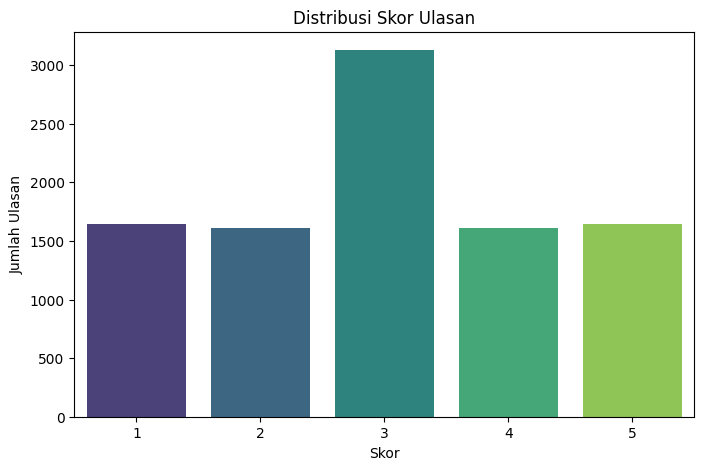

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Distribusi Skor Ulasan')
plt.xlabel('Skor')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
# Sentiment Labeling

# Define a function to label sentiments based on review scores
def label_sentiment(score):
    if score in [1, 2]:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    elif score in [4, 5]:
        return 'Positive'
    else:
        return 'Unknown'

# Apply the sentiment labeling function to the 'score' column
df['label'] = df['score'].apply(label_sentiment)

In [ ]:
df[['score', 'label']].head()

,score,label
0,1,Negative
1,1,Negative
2,1,Negative
3,1,Negative
4,1,Negative


In [ ]:
df[['score', 'label']].tail()

,score,label
9985,5,Positive
9986,5,Positive
9987,5,Positive
9988,5,Positive
9989,5,Positive


In [ ]:
sentiment_distribution = df['score'].value_counts()
print(sentiment_distribution)

score
3    3128
1    1645
5    1644
2    1614
4    1614
Name: count, dtype: int64


C:\Users\Andakara\AppData\Local\Temp\ipykernel_210076\2860644654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='pastel', order=['Negative', 'Neutral', 'Positive'])


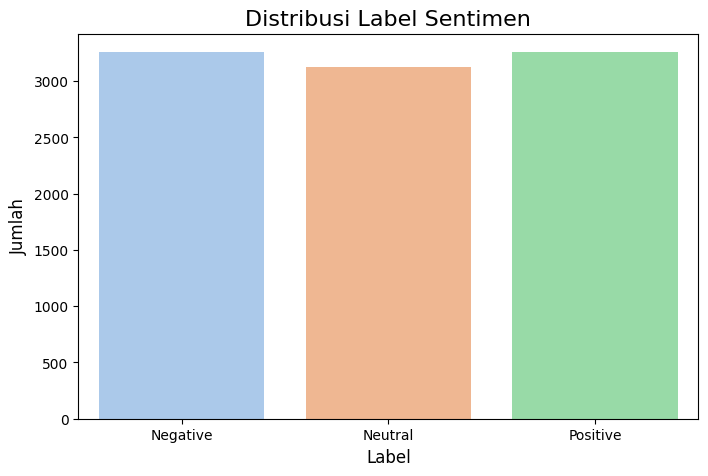

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='pastel', order=['Negative', 'Neutral', 'Positive'])
plt.title('Distribusi Label Sentimen', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [ ]:
df.rename(columns={'cleaned_content': 'text'}, inplace=True)

In [ ]:
labeled_data_file = "data/processed/data.csv"
df[['text', 'label']].to_csv(labeled_data_file, index=False)
print(f"\nData yang sudah dilabel disimpan di {labeled_data_file}")


Data yang sudah dilabel disimpan di data/processed/data.csv


 **✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [ ] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal


# Data Preprocesing

In [ ]:
data = pd.read_csv(labeled_data_file)
data.head()

,text,label
0,the app itself is a good idea i love features ...,Negative
1,this whole update is complete and utter garbag...,Negative
2,not a fan of the explore page features in new ...,Negative
3,the new update is so buggy lets say i am going...,Negative
4,this app is alright when it decides to work th...,Negative


In [ ]:
full_train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(full_train_df, test_size=0.25, random_state=42)

print(f"Ukuran train set: {len(train_df)}")
print(f"Ukuran validation set: {len(val_df)}")
print(f"Ukuran test set: {len(test_df)}")

In [ ]:
label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping)
test_df['label'] = test_df['label'].map(label_mapping)

print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

In [ ]:
ds = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "val": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

## Feature Extraction

### TF-IDF

### Word2Vec

### BERT Embeddings

 **✅ Submission Progress Tracker:**
- [x] Dataset ≥ 10.000 sampel 
- [x] Dataset  ≥ 3 kelas
- [x] Min. 3 skema pelatihan berbeda dengan min. 2 variasi (algoritma / fitur / split / label)
  - [ ] Skema 1: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 2: (Algoritma, Fitur, Split, Akurasi)
  - [ ] Skema 3: (Algoritma, Fitur, Split, Akurasi)
- [ ] Menggunakan algoritma deep learning
- [ ] Akurasi training ≥ 92%
- [ ] Akurasi testing ≥ 92% **atau** min. 3 percobaan testing ≥ 85%
- [ ] Cell inference untuk testing dengan output berupa kelas kategorikal
